# Scatter Matrix

A scatter matrix is the first look at a table with several numeric columns: it draws a scatter chart for every pair of columns at once, so you can see which pairs move together, which groups separate, and where the outliers are, before picking one pair to study in a [scatter chart](../scatterchart/). This guide shows how to create scatter matrices with the [datachart.charts.ScatterMatrix](../../../references/charts/scattermatrix/#datachart.charts.ScatterMatrix) function, starting with the basics and building up to worked examples on real data.

Looking for a specific customization? Jump straight to the [quick reference](#customizing-the-scatter-matrix), which maps common tasks to the parameter or style attribute that does the job.

In [1]:
from datachart.charts import ScatterMatrix

## Basics

The examples in this guide share one dataset: the 342 penguins measured on three islands of the Palmer Archipelago, Antarctica (source: the [Palmer penguins](https://allisonhorst.github.io/palmerpenguins/) dataset, Gorman, Williams and Fraser 2014, released under CC0; the two penguins with no measurements are left out). The data lives in a hidden cell. `penguins` is a list of records, one dictionary per penguin, with four measurements (`"bill length"` and `"bill depth"` in millimeters, `"flipper length"` in millimeters, `"body mass"` in grams) and two categories (`"species"`, one of Adelie, Chinstrap and Gentoo, and `"sex"`, `None` for the nine penguins whose sex was not recorded). `MEASUREMENTS` lists the four measurement names. The table hides a trap that a scatter matrix is good at exposing: pooled over all penguins, deeper bills go with shorter ones, yet within every species the opposite is true.

In [2]:
# Palmer penguins (Gorman et al. 2014, CC0), by species:
# (bill length mm, bill depth mm, flipper length mm, body mass g, sex)
PENGUIN_ROWS = {
    "Adelie": [
        (39.1, 18.7, 181, 3750, "m"), (39.5, 17.4, 186, 3800, "f"), (40.3, 18, 195, 3250, "f"),
        (36.7, 19.3, 193, 3450, "f"), (39.3, 20.6, 190, 3650, "m"), (38.9, 17.8, 181, 3625, "f"),
        (39.2, 19.6, 195, 4675, "m"), (34.1, 18.1, 193, 3475, None), (42, 20.2, 190, 4250, None),
        (37.8, 17.1, 186, 3300, None), (37.8, 17.3, 180, 3700, None), (41.1, 17.6, 182, 3200, "f"),
        (38.6, 21.2, 191, 3800, "m"), (34.6, 21.1, 198, 4400, "m"), (36.6, 17.8, 185, 3700, "f"),
        (38.7, 19, 195, 3450, "f"), (42.5, 20.7, 197, 4500, "m"), (34.4, 18.4, 184, 3325, "f"),
        (46, 21.5, 194, 4200, "m"), (37.8, 18.3, 174, 3400, "f"), (37.7, 18.7, 180, 3600, "m"),
        (35.9, 19.2, 189, 3800, "f"), (38.2, 18.1, 185, 3950, "m"), (38.8, 17.2, 180, 3800, "m"),
        (35.3, 18.9, 187, 3800, "f"), (40.6, 18.6, 183, 3550, "m"), (40.5, 17.9, 187, 3200, "f"),
        (37.9, 18.6, 172, 3150, "f"), (40.5, 18.9, 180, 3950, "m"), (39.5, 16.7, 178, 3250, "f"),
        (37.2, 18.1, 178, 3900, "m"), (39.5, 17.8, 188, 3300, "f"), (40.9, 18.9, 184, 3900, "m"),
        (36.4, 17, 195, 3325, "f"), (39.2, 21.1, 196, 4150, "m"), (38.8, 20, 190, 3950, "m"),
        (42.2, 18.5, 180, 3550, "f"), (37.6, 19.3, 181, 3300, "f"), (39.8, 19.1, 184, 4650, "m"),
        (36.5, 18, 182, 3150, "f"), (40.8, 18.4, 195, 3900, "m"), (36, 18.5, 186, 3100, "f"),
        (44.1, 19.7, 196, 4400, "m"), (37, 16.9, 185, 3000, "f"), (39.6, 18.8, 190, 4600, "m"),
        (41.1, 19, 182, 3425, "m"), (37.5, 18.9, 179, 2975, None), (36, 17.9, 190, 3450, "f"),
        (42.3, 21.2, 191, 4150, "m"), (39.6, 17.7, 186, 3500, "f"), (40.1, 18.9, 188, 4300, "m"),
        (35, 17.9, 190, 3450, "f"), (42, 19.5, 200, 4050, "m"), (34.5, 18.1, 187, 2900, "f"),
        (41.4, 18.6, 191, 3700, "m"), (39, 17.5, 186, 3550, "f"), (40.6, 18.8, 193, 3800, "m"),
        (36.5, 16.6, 181, 2850, "f"), (37.6, 19.1, 194, 3750, "m"), (35.7, 16.9, 185, 3150, "f"),
        (41.3, 21.1, 195, 4400, "m"), (37.6, 17, 185, 3600, "f"), (41.1, 18.2, 192, 4050, "m"),
        (36.4, 17.1, 184, 2850, "f"), (41.6, 18, 192, 3950, "m"), (35.5, 16.2, 195, 3350, "f"),
        (41.1, 19.1, 188, 4100, "m"), (35.9, 16.6, 190, 3050, "f"), (41.8, 19.4, 198, 4450, "m"),
        (33.5, 19, 190, 3600, "f"), (39.7, 18.4, 190, 3900, "m"), (39.6, 17.2, 196, 3550, "f"),
        (45.8, 18.9, 197, 4150, "m"), (35.5, 17.5, 190, 3700, "f"), (42.8, 18.5, 195, 4250, "m"),
        (40.9, 16.8, 191, 3700, "f"), (37.2, 19.4, 184, 3900, "m"), (36.2, 16.1, 187, 3550, "f"),
        (42.1, 19.1, 195, 4000, "m"), (34.6, 17.2, 189, 3200, "f"), (42.9, 17.6, 196, 4700, "m"),
        (36.7, 18.8, 187, 3800, "f"), (35.1, 19.4, 193, 4200, "m"), (37.3, 17.8, 191, 3350, "f"),
        (41.3, 20.3, 194, 3550, "m"), (36.3, 19.5, 190, 3800, "m"), (36.9, 18.6, 189, 3500, "f"),
        (38.3, 19.2, 189, 3950, "m"), (38.9, 18.8, 190, 3600, "f"), (35.7, 18, 202, 3550, "f"),
        (41.1, 18.1, 205, 4300, "m"), (34, 17.1, 185, 3400, "f"), (39.6, 18.1, 186, 4450, "m"),
        (36.2, 17.3, 187, 3300, "f"), (40.8, 18.9, 208, 4300, "m"), (38.1, 18.6, 190, 3700, "f"),
        (40.3, 18.5, 196, 4350, "m"), (33.1, 16.1, 178, 2900, "f"), (43.2, 18.5, 192, 4100, "m"),
        (35, 17.9, 192, 3725, "f"), (41, 20, 203, 4725, "m"), (37.7, 16, 183, 3075, "f"),
        (37.8, 20, 190, 4250, "m"), (37.9, 18.6, 193, 2925, "f"), (39.7, 18.9, 184, 3550, "m"),
        (38.6, 17.2, 199, 3750, "f"), (38.2, 20, 190, 3900, "m"), (38.1, 17, 181, 3175, "f"),
        (43.2, 19, 197, 4775, "m"), (38.1, 16.5, 198, 3825, "f"), (45.6, 20.3, 191, 4600, "m"),
        (39.7, 17.7, 193, 3200, "f"), (42.2, 19.5, 197, 4275, "m"), (39.6, 20.7, 191, 3900, "f"),
        (42.7, 18.3, 196, 4075, "m"), (38.6, 17, 188, 2900, "f"), (37.3, 20.5, 199, 3775, "m"),
        (35.7, 17, 189, 3350, "f"), (41.1, 18.6, 189, 3325, "m"), (36.2, 17.2, 187, 3150, "f"),
        (37.7, 19.8, 198, 3500, "m"), (40.2, 17, 176, 3450, "f"), (41.4, 18.5, 202, 3875, "m"),
        (35.2, 15.9, 186, 3050, "f"), (40.6, 19, 199, 4000, "m"), (38.8, 17.6, 191, 3275, "f"),
        (41.5, 18.3, 195, 4300, "m"), (39, 17.1, 191, 3050, "f"), (44.1, 18, 210, 4000, "m"),
        (38.5, 17.9, 190, 3325, "f"), (43.1, 19.2, 197, 3500, "m"), (36.8, 18.5, 193, 3500, "f"),
        (37.5, 18.5, 199, 4475, "m"), (38.1, 17.6, 187, 3425, "f"), (41.1, 17.5, 190, 3900, "m"),
        (35.6, 17.5, 191, 3175, "f"), (40.2, 20.1, 200, 3975, "m"), (37, 16.5, 185, 3400, "f"),
        (39.7, 17.9, 193, 4250, "m"), (40.2, 17.1, 193, 3400, "f"), (40.6, 17.2, 187, 3475, "m"),
        (32.1, 15.5, 188, 3050, "f"), (40.7, 17, 190, 3725, "m"), (37.3, 16.8, 192, 3000, "f"),
        (39, 18.7, 185, 3650, "m"), (39.2, 18.6, 190, 4250, "m"), (36.6, 18.4, 184, 3475, "f"),
        (36, 17.8, 195, 3450, "f"), (37.8, 18.1, 193, 3750, "m"), (36, 17.1, 187, 3700, "f"),
        (41.5, 18.5, 201, 4000, "m"),
    ],
    "Chinstrap": [
        (46.5, 17.9, 192, 3500, "f"), (50, 19.5, 196, 3900, "m"), (51.3, 19.2, 193, 3650, "m"),
        (45.4, 18.7, 188, 3525, "f"), (52.7, 19.8, 197, 3725, "m"), (45.2, 17.8, 198, 3950, "f"),
        (46.1, 18.2, 178, 3250, "f"), (51.3, 18.2, 197, 3750, "m"), (46, 18.9, 195, 4150, "f"),
        (51.3, 19.9, 198, 3700, "m"), (46.6, 17.8, 193, 3800, "f"), (51.7, 20.3, 194, 3775, "m"),
        (47, 17.3, 185, 3700, "f"), (52, 18.1, 201, 4050, "m"), (45.9, 17.1, 190, 3575, "f"),
        (50.5, 19.6, 201, 4050, "m"), (50.3, 20, 197, 3300, "m"), (58, 17.8, 181, 3700, "f"),
        (46.4, 18.6, 190, 3450, "f"), (49.2, 18.2, 195, 4400, "m"), (42.4, 17.3, 181, 3600, "f"),
        (48.5, 17.5, 191, 3400, "m"), (43.2, 16.6, 187, 2900, "f"), (50.6, 19.4, 193, 3800, "m"),
        (46.7, 17.9, 195, 3300, "f"), (52, 19, 197, 4150, "m"), (50.5, 18.4, 200, 3400, "f"),
        (49.5, 19, 200, 3800, "m"), (46.4, 17.8, 191, 3700, "f"), (52.8, 20, 205, 4550, "m"),
        (40.9, 16.6, 187, 3200, "f"), (54.2, 20.8, 201, 4300, "m"), (42.5, 16.7, 187, 3350, "f"),
        (51, 18.8, 203, 4100, "m"), (49.7, 18.6, 195, 3600, "m"), (47.5, 16.8, 199, 3900, "f"),
        (47.6, 18.3, 195, 3850, "f"), (52, 20.7, 210, 4800, "m"), (46.9, 16.6, 192, 2700, "f"),
        (53.5, 19.9, 205, 4500, "m"), (49, 19.5, 210, 3950, "m"), (46.2, 17.5, 187, 3650, "f"),
        (50.9, 19.1, 196, 3550, "m"), (45.5, 17, 196, 3500, "f"), (50.9, 17.9, 196, 3675, "f"),
        (50.8, 18.5, 201, 4450, "m"), (50.1, 17.9, 190, 3400, "f"), (49, 19.6, 212, 4300, "m"),
        (51.5, 18.7, 187, 3250, "m"), (49.8, 17.3, 198, 3675, "f"), (48.1, 16.4, 199, 3325, "f"),
        (51.4, 19, 201, 3950, "m"), (45.7, 17.3, 193, 3600, "f"), (50.7, 19.7, 203, 4050, "m"),
        (42.5, 17.3, 187, 3350, "f"), (52.2, 18.8, 197, 3450, "m"), (45.2, 16.6, 191, 3250, "f"),
        (49.3, 19.9, 203, 4050, "m"), (50.2, 18.8, 202, 3800, "m"), (45.6, 19.4, 194, 3525, "f"),
        (51.9, 19.5, 206, 3950, "m"), (46.8, 16.5, 189, 3650, "f"), (45.7, 17, 195, 3650, "f"),
        (55.8, 19.8, 207, 4000, "m"), (43.5, 18.1, 202, 3400, "f"), (49.6, 18.2, 193, 3775, "m"),
        (50.8, 19, 210, 4100, "m"), (50.2, 18.7, 198, 3775, "f"),
    ],
    "Gentoo": [
        (46.1, 13.2, 211, 4500, "f"), (50, 16.3, 230, 5700, "m"), (48.7, 14.1, 210, 4450, "f"),
        (50, 15.2, 218, 5700, "m"), (47.6, 14.5, 215, 5400, "m"), (46.5, 13.5, 210, 4550, "f"),
        (45.4, 14.6, 211, 4800, "f"), (46.7, 15.3, 219, 5200, "m"), (43.3, 13.4, 209, 4400, "f"),
        (46.8, 15.4, 215, 5150, "m"), (40.9, 13.7, 214, 4650, "f"), (49, 16.1, 216, 5550, "m"),
        (45.5, 13.7, 214, 4650, "f"), (48.4, 14.6, 213, 5850, "m"), (45.8, 14.6, 210, 4200, "f"),
        (49.3, 15.7, 217, 5850, "m"), (42, 13.5, 210, 4150, "f"), (49.2, 15.2, 221, 6300, "m"),
        (46.2, 14.5, 209, 4800, "f"), (48.7, 15.1, 222, 5350, "m"), (50.2, 14.3, 218, 5700, "m"),
        (45.1, 14.5, 215, 5000, "f"), (46.5, 14.5, 213, 4400, "f"), (46.3, 15.8, 215, 5050, "m"),
        (42.9, 13.1, 215, 5000, "f"), (46.1, 15.1, 215, 5100, "m"), (44.5, 14.3, 216, 4100, None),
        (47.8, 15, 215, 5650, "m"), (48.2, 14.3, 210, 4600, "f"), (50, 15.3, 220, 5550, "m"),
        (47.3, 15.3, 222, 5250, "m"), (42.8, 14.2, 209, 4700, "f"), (45.1, 14.5, 207, 5050, "f"),
        (59.6, 17, 230, 6050, "m"), (49.1, 14.8, 220, 5150, "f"), (48.4, 16.3, 220, 5400, "m"),
        (42.6, 13.7, 213, 4950, "f"), (44.4, 17.3, 219, 5250, "m"), (44, 13.6, 208, 4350, "f"),
        (48.7, 15.7, 208, 5350, "m"), (42.7, 13.7, 208, 3950, "f"), (49.6, 16, 225, 5700, "m"),
        (45.3, 13.7, 210, 4300, "f"), (49.6, 15, 216, 4750, "m"), (50.5, 15.9, 222, 5550, "m"),
        (43.6, 13.9, 217, 4900, "f"), (45.5, 13.9, 210, 4200, "f"), (50.5, 15.9, 225, 5400, "m"),
        (44.9, 13.3, 213, 5100, "f"), (45.2, 15.8, 215, 5300, "m"), (46.6, 14.2, 210, 4850, "f"),
        (48.5, 14.1, 220, 5300, "m"), (45.1, 14.4, 210, 4400, "f"), (50.1, 15, 225, 5000, "m"),
        (46.5, 14.4, 217, 4900, "f"), (45, 15.4, 220, 5050, "m"), (43.8, 13.9, 208, 4300, "f"),
        (45.5, 15, 220, 5000, "m"), (43.2, 14.5, 208, 4450, "f"), (50.4, 15.3, 224, 5550, "m"),
        (45.3, 13.8, 208, 4200, "f"), (46.2, 14.9, 221, 5300, "m"), (45.7, 13.9, 214, 4400, "f"),
        (54.3, 15.7, 231, 5650, "m"), (45.8, 14.2, 219, 4700, "f"), (49.8, 16.8, 230, 5700, "m"),
        (46.2, 14.4, 214, 4650, None), (49.5, 16.2, 229, 5800, "m"), (43.5, 14.2, 220, 4700, "f"),
        (50.7, 15, 223, 5550, "m"), (47.7, 15, 216, 4750, "f"), (46.4, 15.6, 221, 5000, "m"),
        (48.2, 15.6, 221, 5100, "m"), (46.5, 14.8, 217, 5200, "f"), (46.4, 15, 216, 4700, "f"),
        (48.6, 16, 230, 5800, "m"), (47.5, 14.2, 209, 4600, "f"), (51.1, 16.3, 220, 6000, "m"),
        (45.2, 13.8, 215, 4750, "f"), (45.2, 16.4, 223, 5950, "m"), (49.1, 14.5, 212, 4625, "f"),
        (52.5, 15.6, 221, 5450, "m"), (47.4, 14.6, 212, 4725, "f"), (50, 15.9, 224, 5350, "m"),
        (44.9, 13.8, 212, 4750, "f"), (50.8, 17.3, 228, 5600, "m"), (43.4, 14.4, 218, 4600, "f"),
        (51.3, 14.2, 218, 5300, "m"), (47.5, 14, 212, 4875, "f"), (52.1, 17, 230, 5550, "m"),
        (47.5, 15, 218, 4950, "f"), (52.2, 17.1, 228, 5400, "m"), (45.5, 14.5, 212, 4750, "f"),
        (49.5, 16.1, 224, 5650, "m"), (44.5, 14.7, 214, 4850, "f"), (50.8, 15.7, 226, 5200, "m"),
        (49.4, 15.8, 216, 4925, "m"), (46.9, 14.6, 222, 4875, "f"), (48.4, 14.4, 203, 4625, "f"),
        (51.1, 16.5, 225, 5250, "m"), (48.5, 15, 219, 4850, "f"), (55.9, 17, 228, 5600, "m"),
        (47.2, 15.5, 215, 4975, "f"), (49.1, 15, 228, 5500, "m"), (47.3, 13.8, 216, 4725, None),
        (46.8, 16.1, 215, 5500, "m"), (41.7, 14.7, 210, 4700, "f"), (53.4, 15.8, 219, 5500, "m"),
        (43.3, 14, 208, 4575, "f"), (48.1, 15.1, 209, 5500, "m"), (50.5, 15.2, 216, 5000, "f"),
        (49.8, 15.9, 229, 5950, "m"), (43.5, 15.2, 213, 4650, "f"), (51.5, 16.3, 230, 5500, "m"),
        (46.2, 14.1, 217, 4375, "f"), (55.1, 16, 230, 5850, "m"), (44.5, 15.7, 217, 4875, None),
        (48.8, 16.2, 222, 6000, "m"), (47.2, 13.7, 214, 4925, "f"), (46.8, 14.3, 215, 4850, "f"),
        (50.4, 15.7, 222, 5750, "m"), (45.2, 14.8, 212, 5200, "f"), (49.9, 16.1, 213, 5400, "m"),
    ],
}
MEASUREMENTS = ["bill length", "bill depth", "flipper length", "body mass"]
SEXES = {"f": "female", "m": "male", None: None}

penguins = [
    {**dict(zip(MEASUREMENTS, row[:4])), "species": species, "sex": SEXES[row[4]]}
    for species, rows in PENGUIN_ROWS.items()
    for row in rows
]

Each record is one penguin:

In [3]:
penguins[:3]

[{'bill length': 39.1,
  'bill depth': 18.7,
  'flipper length': 181,
  'body mass': 3750,
  'species': 'Adelie',
  'sex': 'male'},
 {'bill length': 39.5,
  'bill depth': 17.4,
  'flipper length': 186,
  'body mass': 3800,
  'species': 'Adelie',
  'sex': 'female'},
 {'bill length': 40.3,
  'bill depth': 18,
  'flipper length': 195,
  'body mass': 3250,
  'species': 'Adelie',
  'sex': 'female'}]

**Basic example.** Only the `data` argument is required. Every numeric column becomes a dimension, in the order the columns first appear, so the four measurements make a four-by-four matrix and the text columns are left out. Each cell below the diagonal plots the variable of its row (y-axis) against the variable of its column (x-axis), the diagonal shows a histogram of each variable, and the cells above the diagonal mirror the ones below. Flipper length and body mass rise together almost on a line; the other pairs form clumps, a first hint that the table mixes groups.

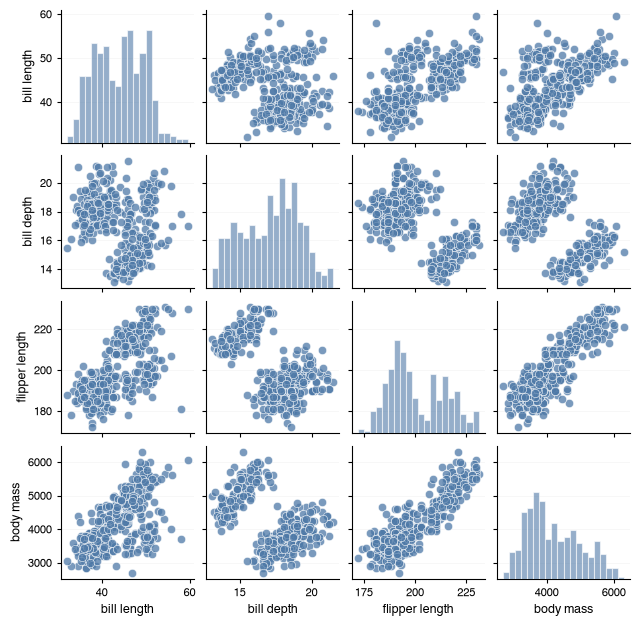

In [4]:
ScatterMatrix(
    # add the data to the chart
    data=penguins,
).show()

## Customizing the Scatter Matrix

Every customization is either a keyword argument of `ScatterMatrix` or an attribute of its `style` dictionary. The table maps common tasks to the one you need and links to the subsection that shows it.

| I want to…                                      | Use                                   | See |
| :---------------------------------------------- | :------------------------------------ | :-- |
| add a title or resize the figure                | `title`, `figsize`                    | [Title and figure size](#title-and-figure-size) |
| pass the table as columns instead of records    | `data` as a dictionary of lists       | [Columns or records](#columns-or-records) |
| choose and order the variables                  | `dimensions`                          | [Selecting dimensions](#selecting-dimensions) |
| color the points by a category                  | `hue`                                 | [Hue groups](#hue-groups) |
| show a density curve or nothing on the diagonal | `diagonal`                            | [Diagonal](#diagonal) |
| drop the mirrored cells                         | `lower_only`                          | [Lower triangle only](#lower-triangle-only) |
| print the correlation of each pair              | `show_correlation`                    | [Correlation](#correlation) |
| fit a line to each group                        | `show_regression`                     | [Regression lines](#regression-lines) |
| give each cell its own axis range               | `sharex`, `sharey`                    | [Shared axes](#shared-axes) |
| show grid lines                                 | `show_grid`                           | [Grid lines](#grid-lines) |
| title, arrange or hide the legend               | `legend`, `show_legend`               | [Legend](#legend) |
| restyle points, bars, curves and lines          | `style`                               | [Scatter matrix style](#scatter-matrix-style) |
| put two matrices side by side                   | `Grid`                                | [Scatter matrices in a Grid](#scatter-matrices-in-a-grid) |
| change the whole look at once                   | `config.set_theme`                    | [Themes](#themes) |
| save the chart to a file                        | `save_figure`                         | [Saving Figures](../../utility/saving/) guide |

The parameters that accept a constant, with the class in [datachart.constants](../../../references/constants/) that lists its values:

| Parameter | Constant |
| :-- | :-- |
| `diagonal` | [`SCATTER_MATRIX_DIAGONAL`](../../../references/constants/#datachart.constants.SCATTER_MATRIX_DIAGONAL) |
| `figsize` | [`FIG_SIZE`](../../../references/constants/#datachart.constants.FIG_SIZE) |
| `legend={"location": ..., "alignment": ...}` | [`LEGEND_LOCATION`](../../../references/constants/#datachart.constants.LEGEND_LOCATION), [`LEGEND_ALIGN`](../../../references/constants/#datachart.constants.LEGEND_ALIGN) |
| `show_grid` | [`SHOW_GRID`](../../../references/constants/#datachart.constants.SHOW_GRID) |

The full list of style attributes is in the [datachart.typings.ScatterMatrixStyleAttrs](../../../references/charts/scattermatrix/#datachart.typings.ScatterMatrixStyleAttrs) type; the full list of parameters is in the [datachart.charts.ScatterMatrix](../../../references/charts/scattermatrix/#datachart.charts.ScatterMatrix) reference.

### Title and figure size

A matrix of sixteen cells needs a title to say what table it shows, and `title` adds one above the whole figure. By default every cell gets 2.2 inches a side, shrunk so the whole figure fits a page width of 6.3 inches; a four-by-four matrix gets cells of about 1.6 inches. `figsize` takes a `(width, height)` tuple in inches for the whole figure instead, and the cells stay square inside it; here it adds height for the title. The title is also the place for the units, since the axis labels are the column names.

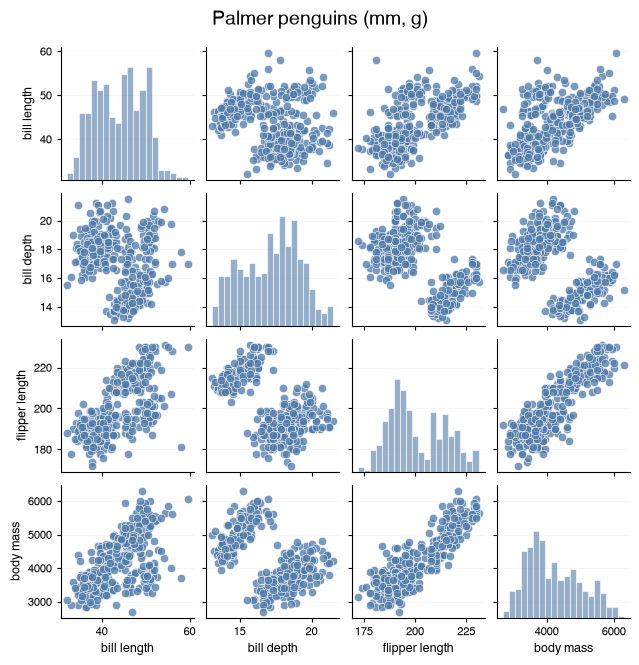

In [5]:
ScatterMatrix(
    data=penguins,
    # say what the table is, and its units
    title="Palmer penguins (mm, g)",
    # the whole figure, not one cell
    figsize=(6.3, 6.6),
).show()

### Columns or records

Data rarely arrives as a list of records: a CSV reader or a data frame hands over one list per column. `data` also takes a dictionary of equal-length columns, and draws the same matrix. Records suit data built row by row; columns suit data read column by column (`frame.to_dict("list")` turns a pandas data frame into this shape). Unlike most charts, a scatter matrix draws one table, so `data` is never a list of tables. Here the three bill and flipper measurements, as columns:

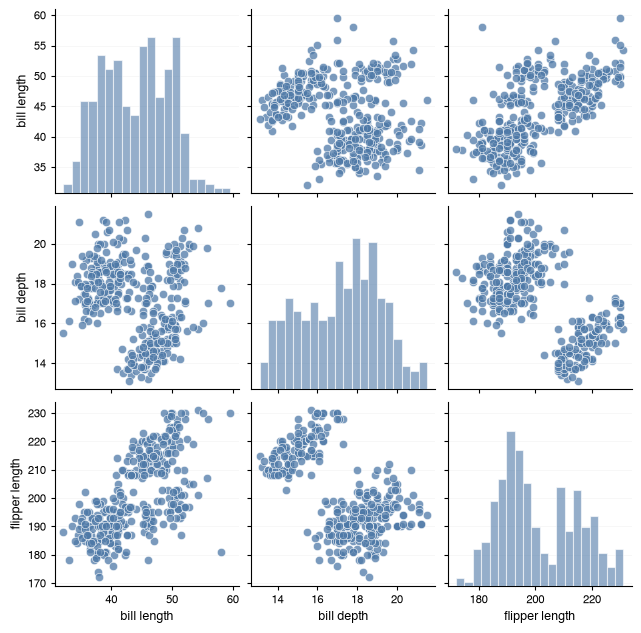

In [6]:
columns = {name: [penguin[name] for penguin in penguins] for name in MEASUREMENTS[:3]}

ScatterMatrix(
    # one list per column instead of one dictionary per penguin
    data=columns,
).show()

### Selecting dimensions

A wide table makes a matrix too large to read, and the column order decides which pairs sit next to each other. `dimensions` lists the numeric columns to plot, in order: the first labels the top row and the left column. Here the two bill measurements come first, since their relationship is the story of this guide, followed by body mass. Missing values (`None`) are left out pair by pair, so a record missing one measurement still appears in every cell that does not need it.

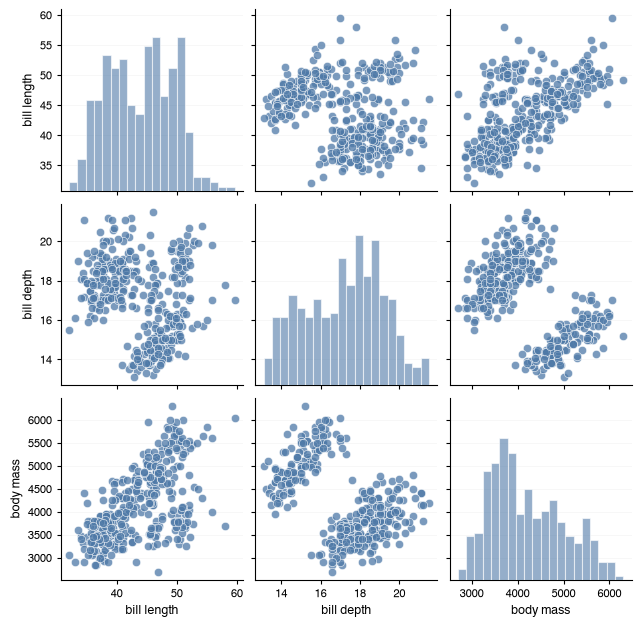

In [7]:
BILL_AND_MASS = ["bill length", "bill depth", "body mass"]

ScatterMatrix(
    data=penguins,
    # three measurements, bills first
    dimensions=BILL_AND_MASS,
).show()

### Hue groups

The clumps in the matrix above are the three species, and naming them turns clumps into an answer. `hue` names a categorical column: every category gets one color from the theme's palette, the same color in every cell, and one legend beside the matrix names them all. The diagonal overlays one histogram per category. Colored by species, the bill cells separate cleanly: Adelie penguins have short, deep bills, Gentoo penguins long, shallow ones, and Chinstrap penguins long, deep ones. The hue column must be text and must have no missing values; a numeric column raises an error, so bin it into categories first.

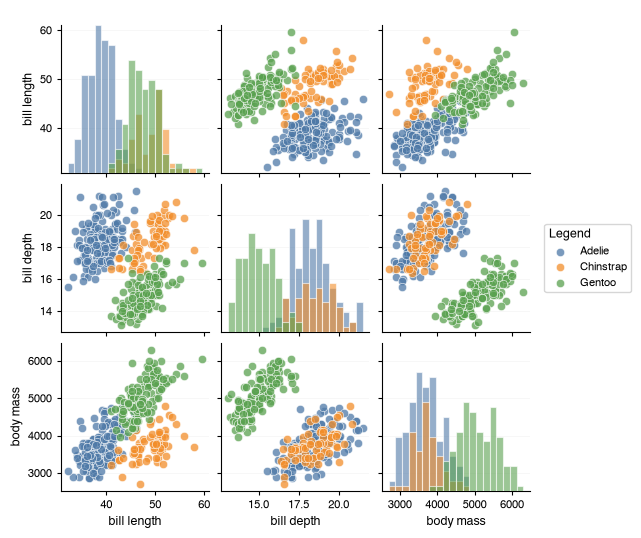

In [8]:
ScatterMatrix(
    data=penguins,
    dimensions=BILL_AND_MASS,
    # one color per species, one legend for the figure
    hue="species",
).show()

### Diagonal

The diagonal cell of a variable shows its own distribution, and the right view depends on the question ([SCATTER_MATRIX_DIAGONAL](../../../references/constants/#datachart.constants.SCATTER_MATRIX_DIAGONAL)). `SCATTER_MATRIX_DIAGONAL.HIST`, the default, draws a histogram: honest about the counts, but overlaid histograms of several groups get busy. `SCATTER_MATRIX_DIAGONAL.KDE` draws one smooth density curve per hue group, the clearest way to compare where the groups sit on one variable. The diagonal cell's axis shows its row's scale, like the other cells; the height of the histogram or curve is drawn to its own, unlabelled scale. The density curves show that bill length alone tells Adelie penguins apart, while bill depth alone tells Gentoo penguins apart.

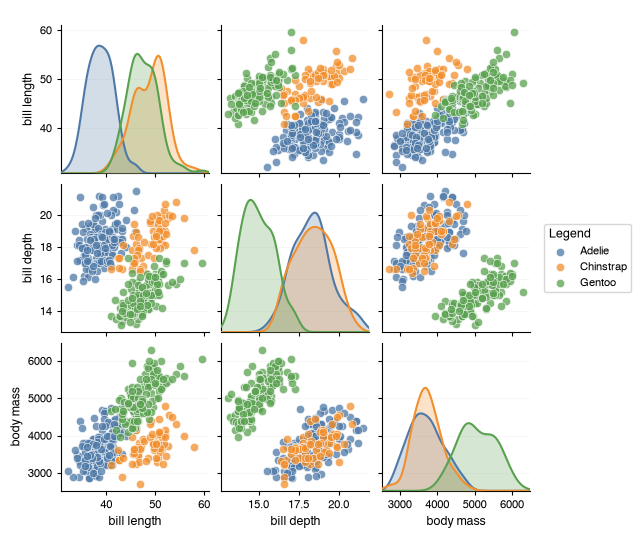

In [9]:
from datachart.constants import SCATTER_MATRIX_DIAGONAL

ScatterMatrix(
    data=penguins,
    dimensions=BILL_AND_MASS,
    hue="species",
    # one density curve per species
    diagonal=SCATTER_MATRIX_DIAGONAL.KDE,
).show()

When the distributions are not the question, `SCATTER_MATRIX_DIAGONAL.BLANK` leaves the diagonal blank, which suits a matrix whose readers only care about the pairs. The tick labels and variable names move to the outermost cell that is drawn:

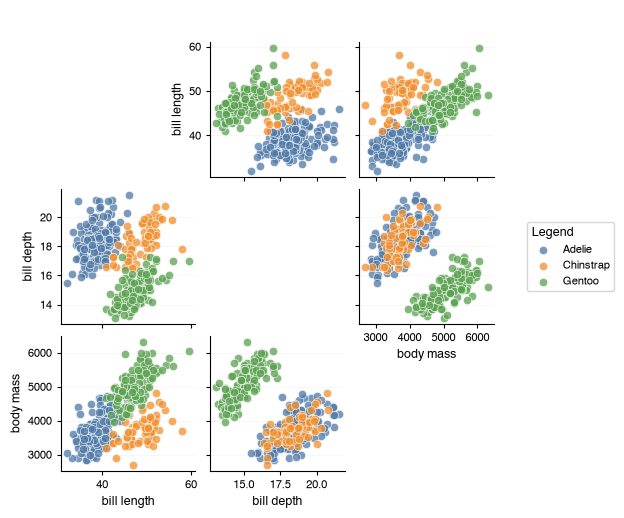

In [10]:
ScatterMatrix(
    data=penguins,
    dimensions=BILL_AND_MASS,
    hue="species",
    # nothing on the diagonal
    diagonal=SCATTER_MATRIX_DIAGONAL.BLANK,
).show()

### Lower triangle only

The cells above the diagonal repeat the cells below it with the axes swapped, so half the matrix is redundant. `lower_only=True` leaves the upper cells empty, which halves the ink and makes a large matrix easier to scan:

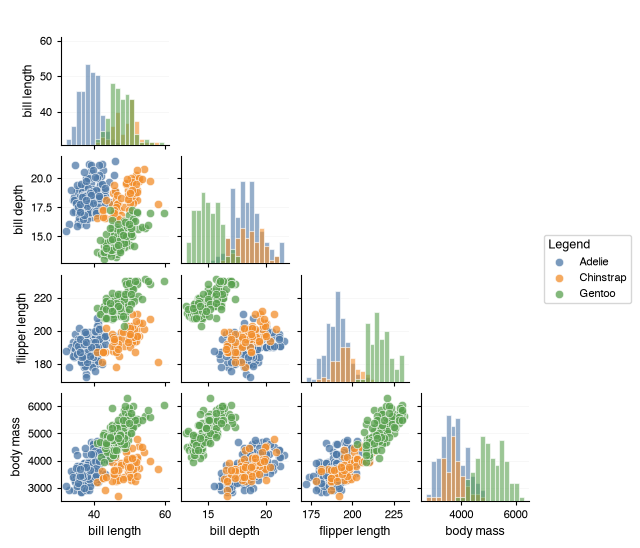

In [11]:
ScatterMatrix(
    data=penguins,
    hue="species",
    # draw only the cells below the diagonal
    lower_only=True,
).show()

With a blank diagonal as well, the empty top row and right column are dropped, so the four measurements take a three-by-three grid:

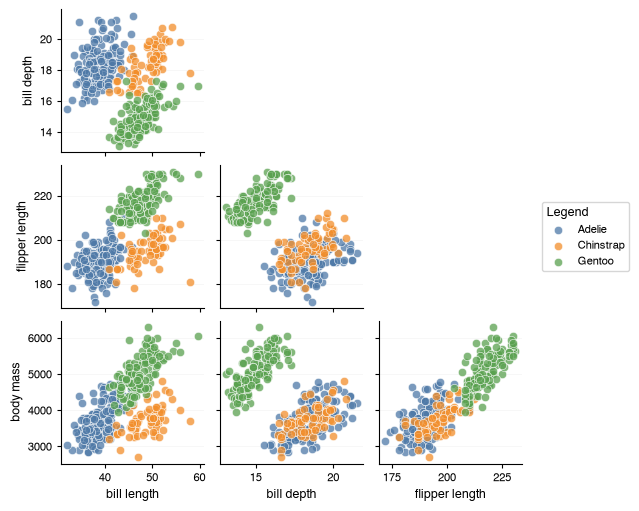

In [12]:
ScatterMatrix(
    data=penguins,
    hue="species",
    lower_only=True,
    # no diagonal: the empty top row and right column go
    diagonal=SCATTER_MATRIX_DIAGONAL.BLANK,
).show()

### Correlation

A cloud of points shows the shape of a relationship, but not its strength as a number. `show_correlation=True` replaces the cells above the diagonal with the Pearson correlation coefficient of each pair, from -1 (a perfect falling line) to 1 (a perfect rising line). Pooled over all penguins, bill length and bill depth have a coefficient of -0.24: deeper bills seem to go with shorter ones. `lower_only` wins over `show_correlation`: with both set, the upper cells stay empty. The same coefficient is available in code as [datachart.utils.stats.correlation](../../../references/utils/stats/#datachart.utils.stats.correlation).

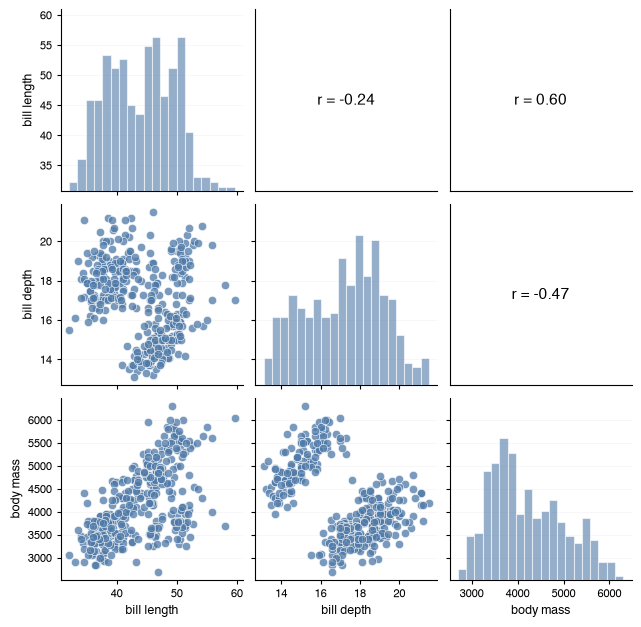

In [13]:
ScatterMatrix(
    data=penguins,
    dimensions=BILL_AND_MASS,
    # print the correlation of each pair above the diagonal
    show_correlation=True,
).show()

With a `hue`, each cell prints one coefficient per group, in the group's color, and the story flips. Within every species, bill length and bill depth rise together (0.39, 0.65 and 0.64), the opposite of the pooled -0.24. This is Simpson's paradox: Gentoo penguins have the longest and the shallowest bills, so pooling the species creates a falling trend that no single species has. Always split by the groups you know about before trusting a pooled coefficient.

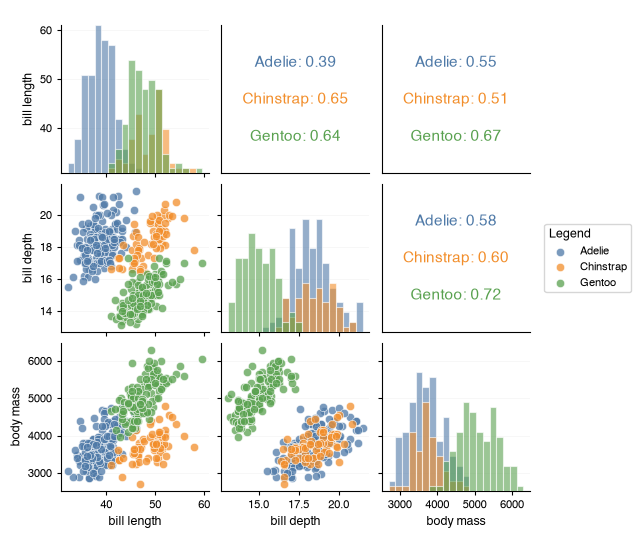

In [14]:
ScatterMatrix(
    data=penguins,
    dimensions=BILL_AND_MASS,
    # one coefficient per species
    hue="species",
    show_correlation=True,
).show()

### Regression lines

A coefficient summarizes a trend; a line shows it where the points are. `show_regression=True` fits a least-squares line to each hue group in every scatter cell, in the group's color. In the bill cell every species slopes up, while the three clusters themselves sit on a falling diagonal: the paradox in one picture. With 342 points the lines are hard to pick out; the [Scatter matrix style](#scatter-matrix-style) section below makes them stand out.

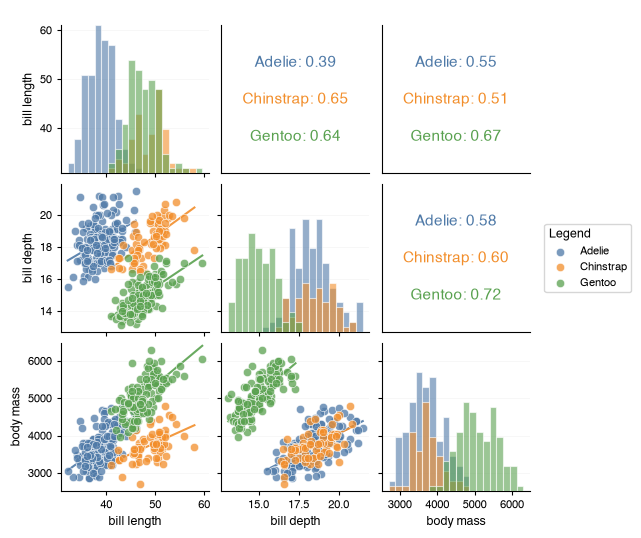

In [15]:
ScatterMatrix(
    data=penguins,
    dimensions=BILL_AND_MASS,
    hue="species",
    # a least-squares line per species
    show_regression=True,
    show_correlation=True,
).show()

### Shared axes

By default the cells of a column share one x-axis and the cells of a row share one y-axis, the diagonal cells included: only the bottom row and the left column label their ticks, and a point sits at the same position in every cell of its row. That is what makes the matrix scannable. When a group is small and its cells cramped, `sharex=False` and `sharey=False` fit each cell to its own data instead; every cell then labels its own ticks, and the diagonal shows its counts or densities. Here only the Chinstrap penguins are plotted, so each cell zooms in on one species:

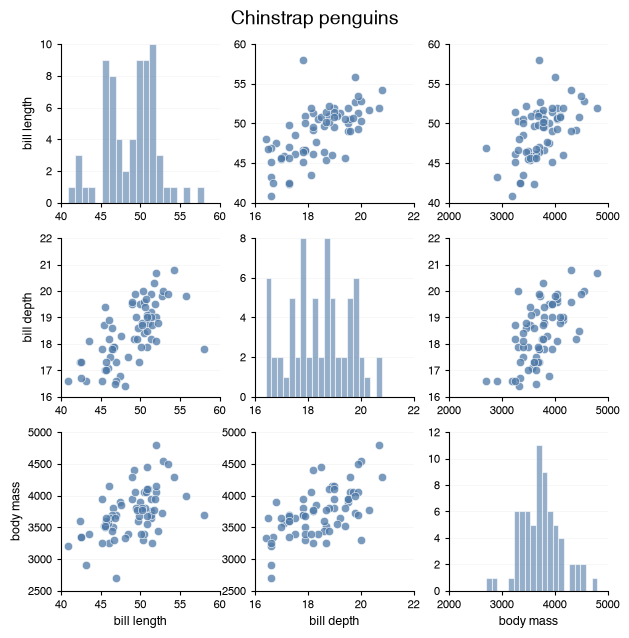

In [16]:
chinstraps = [penguin for penguin in penguins if penguin["species"] == "Chinstrap"]

ScatterMatrix(
    data=chinstraps,
    dimensions=BILL_AND_MASS,
    title="Chinstrap penguins",
    # fit every cell to its own data
    sharex=False,
    sharey=False,
).show()

### Grid lines

Grid lines help read a point's value off the axes of a crowded cell, far from the tick labels. `show_grid` draws them in every scatter and diagonal cell ([SHOW_GRID](../../../references/constants/#datachart.constants.SHOW_GRID)): `SHOW_GRID.BOTH`, `SHOW_GRID.X` or `SHOW_GRID.Y`. The cells with correlation text never show them.

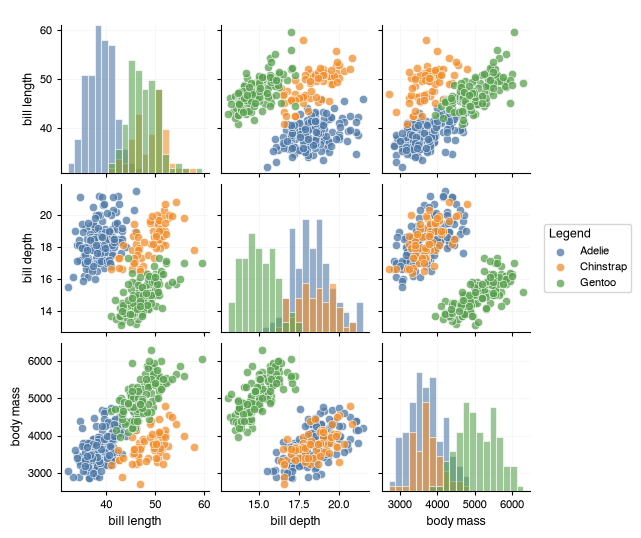

In [17]:
from datachart.constants import SHOW_GRID

ScatterMatrix(
    data=penguins,
    dimensions=BILL_AND_MASS,
    hue="species",
    # grid lines on both axes of every cell
    show_grid=SHOW_GRID.BOTH,
).show()

### Legend

With a `hue`, one legend beside the matrix names the groups, whatever the number of cells, and the hue column's name titles it. A column name is often a poor legend title, and `legend` sets the `title` (an empty string hides it), the number of columns `ncols` and the `alignment` of the entries ([LEGEND_ALIGN](../../../references/constants/#datachart.constants.LEGEND_ALIGN)); see [LegendSettingAttrs](../../../references/typings/#datachart.typings.LegendSettingAttrs). The legend sits outside the cells, so its `location` takes one of the four outside edges of [LEGEND_LOCATION](../../../references/constants/#datachart.constants.LEGEND_LOCATION): `OUTSIDE_RIGHT`, the default, `OUTSIDE_LEFT`, `OUTSIDE_TOP` or `OUTSIDE_BOTTOM`; any other location raises an error. Above or below the matrix, the entries sit side by side in one row, which leaves the full page width to the cells. `show_legend=False` hides the legend, for a figure whose caption already names the colors.

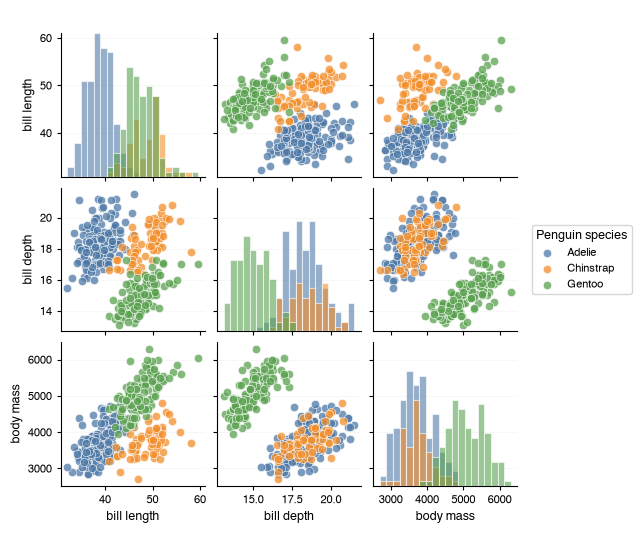

In [18]:
from datachart.constants import LEGEND_LOCATION

ScatterMatrix(
    data=penguins,
    dimensions=BILL_AND_MASS,
    hue="species",
    # a proper title, and one row of entries under the matrix
    legend={"title": "Penguin species", "location": LEGEND_LOCATION.OUTSIDE_BOTTOM},
).show()

### Scatter matrix style

With 342 penguins the points overlap, and the regression lines drown in them. `style` applies to every cell. The points take the `plot_scatter_*` attributes and the histograms the `plot_hist_*` attributes, as in the [scatter chart](../scatterchart/) and the [histogram](../histogram/); the `plot_scatter_matrix_*` attributes style what the matrix adds: the regression lines, the correlation text, the density curves and the transparency of the overlaid histograms. The current values come from the [config](../../styling/themes/#what-a-theme-controls):

In [19]:
from datachart.config import config

{key: value for key, value in config.config.items() if key.startswith("plot_scatter_matrix_")}

{'plot_scatter_matrix_regression_color': None,
 'plot_scatter_matrix_regression_width': 1.5,
 'plot_scatter_matrix_regression_style': '-',
 'plot_scatter_matrix_correlation_size': 11,
 'plot_scatter_matrix_correlation_weight': 'normal',
 'plot_scatter_matrix_kde_width': 1.5,
 'plot_scatter_matrix_kde_alpha': 0.25,
 'plot_scatter_matrix_diagonal_alpha': 0.6}

Smaller, fainter points let the density show through, dashed dark lines stand out from any group color, and thin unfilled density curves keep the diagonal light:

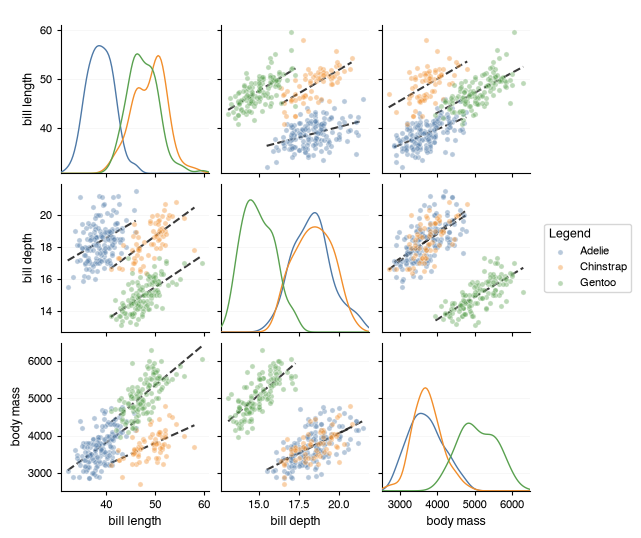

In [20]:
from datachart.constants import LINE_STYLE

ScatterMatrix(
    data=penguins,
    dimensions=BILL_AND_MASS,
    hue="species",
    diagonal=SCATTER_MATRIX_DIAGONAL.KDE,
    show_regression=True,
    style={
        # smaller, fainter points
        "plot_scatter_size": 14,
        "plot_scatter_alpha": 0.4,
        # dark dashed regression lines
        "plot_scatter_matrix_regression_color": "#222222",
        "plot_scatter_matrix_regression_style": LINE_STYLE.DASHED,
        # thin density curves without a fill
        "plot_scatter_matrix_kde_width": 1.0,
        "plot_scatter_matrix_kde_alpha": 0,
    },
).show()

## Multiple Scatter Matrices

A scatter matrix owns its whole grid of axes, so it cannot be overlaid on another chart with [datachart.utils.Panel](../../../references/utils/#datachart.utils.Panel). It can sit beside other charts, or beside another matrix, in a [datachart.utils.Grid](../../../references/utils/#datachart.utils.Grid).

### Scatter matrices in a Grid

Two groupings of the same table are easiest to compare side by side. `Grid` places each matrix in one cell, with its title as the cell's heading. Colored by species, the two bill measurements split into three clusters; colored by sex, the colors mix within every cluster. Males have somewhat larger bills than females of their species, but the differences between species are far larger, so species is the grouping to split by. The penguins without a recorded sex are left out, since a `hue` column cannot have missing values.

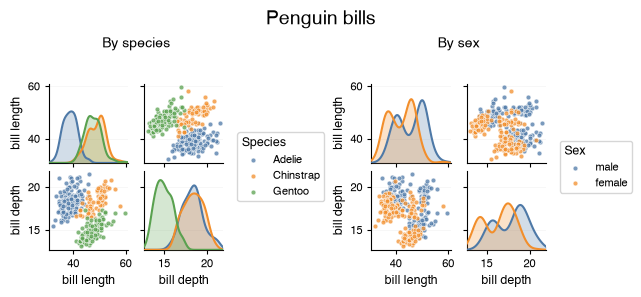

In [21]:
from datachart.utils import Grid

sexed = [penguin for penguin in penguins if penguin["sex"] is not None]

by_species = ScatterMatrix(
    data=sexed,
    dimensions=["bill length", "bill depth"],
    hue="species",
    diagonal=SCATTER_MATRIX_DIAGONAL.KDE,
    legend={"title": "Species"},
    style={"plot_scatter_size": 12},
    title="By species",
)
by_sex = ScatterMatrix(
    data=sexed,
    dimensions=["bill length", "bill depth"],
    hue="sex",
    diagonal=SCATTER_MATRIX_DIAGONAL.KDE,
    legend={"title": "Sex"},
    style={"plot_scatter_size": 12},
    title="By sex",
)

# one matrix per cell
Grid([[by_species, by_sex]], title="Penguin bills", figsize=(6.3, 3.0)).show()

## Additional Features

### Themes

A theme sets the palette, the fonts and the marks of every cell at once, which matters for a matrix of many cells that a per-call `style` would have to restyle one attribute at a time. Apply one with [datachart.config.Config.set_theme](../../../references/config/#datachart.config.Config.set_theme); the [Theme Gallery](../../styling/theme-gallery/) shows every chart under each theme. The figure is drawn when the chart is created, so the theme is reset right after:

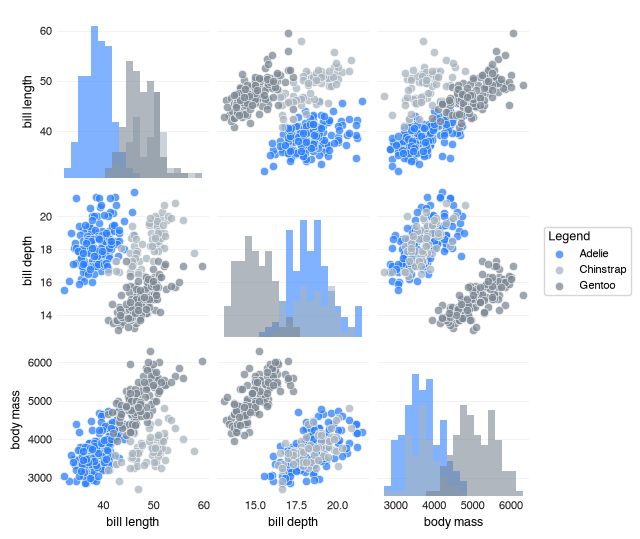

In [22]:
from datachart.constants import THEME

config.set_theme(THEME.MINIMAL)
figure = ScatterMatrix(
    data=penguins,
    dimensions=BILL_AND_MASS,
    hue="species",
)
config.set_theme(THEME.DEFAULT)
figure.show()

## Real-World Examples

The examples below put the features above to work on real or realistic data, each one answering a question. The data lives in hidden cells; each example says what its data is and where it comes from.

### Example 1: Which Car Specs Predict Fuel Economy? (Density Diagonal, Correlation and Regression)

`cars` holds four columns for the 32 cars of the classic `mtcars` table (Henderson and Velleman 1981, from the 1974 *Motor Trend* US magazine): fuel economy in miles per gallon (`"mpg"`), gross horsepower (`"horsepower"`), weight in thousands of pounds (`"weight"`) and the number of cylinders (`"cylinders"`, as text so it can color the points). The question is which spec tracks fuel economy most closely. Coloring by cylinders shows that the engine size already splits the cars into three bands, the density curves on the diagonal show how far apart the bands sit, and the correlations and regression lines show how much of the trend survives within each band. Pooled over all cars, weight (r = -0.87) and horsepower (r = -0.78) both track fuel economy. Within each engine size, weight still does (-0.65 to -0.71), while the link to horsepower weakens (-0.13 to -0.52): heavier cars use more fuel whatever their engine.

In [23]:
# mtcars (Henderson and Velleman 1981; Motor Trend, 1974):
# (model, miles per gallon, gross horsepower, weight in 1000 lb, cylinders)
CAR_ROWS = [
    ("Mazda RX4", 21, 110, 2.62, 6),
    ("Mazda RX4 Wag", 21, 110, 2.875, 6),
    ("Datsun 710", 22.8, 93, 2.32, 4),
    ("Hornet 4 Drive", 21.4, 110, 3.215, 6),
    ("Hornet Sportabout", 18.7, 175, 3.44, 8),
    ("Valiant", 18.1, 105, 3.46, 6),
    ("Duster 360", 14.3, 245, 3.57, 8),
    ("Merc 240D", 24.4, 62, 3.19, 4),
    ("Merc 230", 22.8, 95, 3.15, 4),
    ("Merc 280", 19.2, 123, 3.44, 6),
    ("Merc 280C", 17.8, 123, 3.44, 6),
    ("Merc 450SE", 16.4, 180, 4.07, 8),
    ("Merc 450SL", 17.3, 180, 3.73, 8),
    ("Merc 450SLC", 15.2, 180, 3.78, 8),
    ("Cadillac Fleetwood", 10.4, 205, 5.25, 8),
    ("Lincoln Continental", 10.4, 215, 5.424, 8),
    ("Chrysler Imperial", 14.7, 230, 5.345, 8),
    ("Fiat 128", 32.4, 66, 2.2, 4),
    ("Honda Civic", 30.4, 52, 1.615, 4),
    ("Toyota Corolla", 33.9, 65, 1.835, 4),
    ("Toyota Corona", 21.5, 97, 2.465, 4),
    ("Dodge Challenger", 15.5, 150, 3.52, 8),
    ("AMC Javelin", 15.2, 150, 3.435, 8),
    ("Camaro Z28", 13.3, 245, 3.84, 8),
    ("Pontiac Firebird", 19.2, 175, 3.845, 8),
    ("Fiat X1-9", 27.3, 66, 1.935, 4),
    ("Porsche 914-2", 26, 91, 2.14, 4),
    ("Lotus Europa", 30.4, 113, 1.513, 4),
    ("Ford Pantera L", 15.8, 264, 3.17, 8),
    ("Ferrari Dino", 19.7, 175, 2.77, 6),
    ("Maserati Bora", 15, 335, 3.57, 8),
    ("Volvo 142E", 21.4, 109, 2.78, 4),
]

cars = [
    {"mpg": mpg, "horsepower": hp, "weight": wt, "cylinders": f"{cyl} cylinders"}
    for _, mpg, hp, wt, cyl in sorted(CAR_ROWS, key=lambda row: row[4])
]

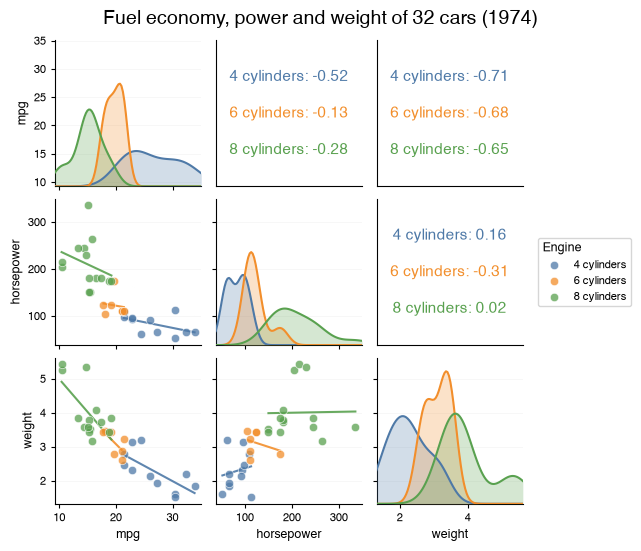

In [24]:
ScatterMatrix(
    data=cars,
    hue="cylinders",
    # one density curve per engine size
    diagonal=SCATTER_MATRIX_DIAGONAL.KDE,
    # the strength and the slope of each trend, per engine size
    show_correlation=True,
    show_regression=True,
    legend={"title": "Engine"},
    title="Fuel economy, power and weight of 32 cars (1974)",
    figsize=(6.3, 5.4),
).show()

### Example 2: Which Evaluation Metrics Move Together? (Lower Triangle, Blank Diagonal and Regression)

`runs` holds the scores of twenty training runs of a classifier with different decision thresholds (illustrative values): precision, recall, F1 and the mean prediction latency in milliseconds. Before reporting one metric, it is worth knowing which ones carry the same information. Only the pairs matter, so the matrix drops the redundant upper cells and the diagonal, and a regression line per cell shows the trend. Precision and recall trade off along a falling line. Recall moves more than precision across these thresholds, so F1 follows recall and falls as precision rises: reporting F1 alone would hide the precision gain. Latency is unrelated to the other three; its slopes are noise.

In [25]:
import numpy as np

# illustrative scores of twenty classifier runs at different decision thresholds
rng = np.random.RandomState(42)
threshold = np.linspace(0.2, 0.8, 20)
precision = 0.62 + 0.35 * threshold + rng.normal(0, 0.015, 20)
recall = 0.97 - 0.45 * threshold + rng.normal(0, 0.015, 20)

runs = {
    "precision": precision.round(3).tolist(),
    "recall": recall.round(3).tolist(),
    "F1": (2 * precision * recall / (precision + recall)).round(3).tolist(),
    "latency (ms)": rng.normal(40, 3, 20).round(1).tolist(),
}

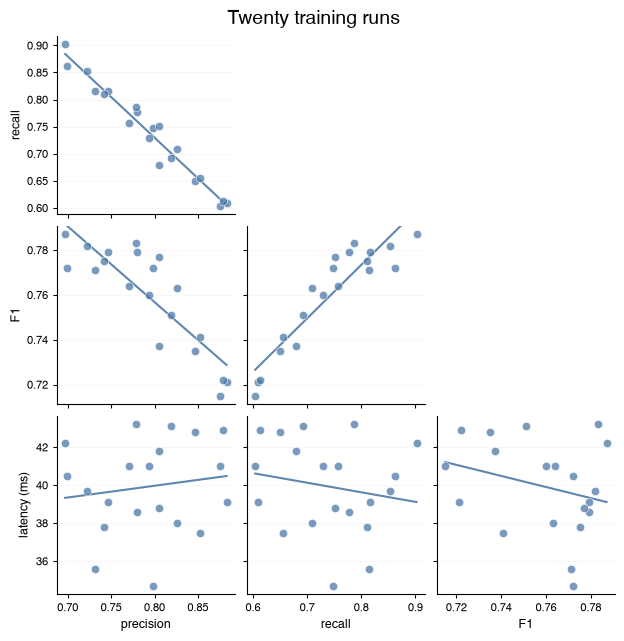

In [26]:
ScatterMatrix(
    data=runs,
    # only the pairs: no upper cells, no diagonal
    lower_only=True,
    diagonal=SCATTER_MATRIX_DIAGONAL.BLANK,
    # the trend of each pair
    show_regression=True,
    title="Twenty training runs",
).show()

### Example 3: Do Sepals or Petals Tell the Iris Species Apart? (Two Matrices in a Grid)

`sepals` and `petals` hold the length and width, in centimeters, of the sepals and the petals of 150 iris flowers, 50 of each species (source: Anderson 1935, published by Fisher 1936, the classic `iris` dataset). The question is which part of the flower tells the species apart. Two small matrices in a `Grid` put the answer side by side: the sepal clouds of *versicolor* and *virginica* overlap, while the petal clouds separate all three species, *setosa* by a wide margin. The density curves on the diagonals show the same thing one measurement at a time, and one legend is enough for the two matrices.

In [27]:
# Anderson's iris data (Fisher 1936):
# (sepal length, sepal width, petal length, petal width) in cm, by species
IRIS_ROWS = {
    "setosa": [
        (5.1, 3.5, 1.4, 0.2), (4.9, 3.0, 1.4, 0.2), (4.7, 3.2, 1.3, 0.2), (4.6, 3.1, 1.5, 0.2), (5.0, 3.6, 1.4, 0.2),
        (5.4, 3.9, 1.7, 0.4), (4.6, 3.4, 1.4, 0.3), (5.0, 3.4, 1.5, 0.2), (4.4, 2.9, 1.4, 0.2), (4.9, 3.1, 1.5, 0.1),
        (5.4, 3.7, 1.5, 0.2), (4.8, 3.4, 1.6, 0.2), (4.8, 3.0, 1.4, 0.1), (4.3, 3.0, 1.1, 0.1), (5.8, 4.0, 1.2, 0.2),
        (5.7, 4.4, 1.5, 0.4), (5.4, 3.9, 1.3, 0.4), (5.1, 3.5, 1.4, 0.3), (5.7, 3.8, 1.7, 0.3), (5.1, 3.8, 1.5, 0.3),
        (5.4, 3.4, 1.7, 0.2), (5.1, 3.7, 1.5, 0.4), (4.6, 3.6, 1.0, 0.2), (5.1, 3.3, 1.7, 0.5), (4.8, 3.4, 1.9, 0.2),
        (5.0, 3.0, 1.6, 0.2), (5.0, 3.4, 1.6, 0.4), (5.2, 3.5, 1.5, 0.2), (5.2, 3.4, 1.4, 0.2), (4.7, 3.2, 1.6, 0.2),
        (4.8, 3.1, 1.6, 0.2), (5.4, 3.4, 1.5, 0.4), (5.2, 4.1, 1.5, 0.1), (5.5, 4.2, 1.4, 0.2), (4.9, 3.1, 1.5, 0.2),
        (5.0, 3.2, 1.2, 0.2), (5.5, 3.5, 1.3, 0.2), (4.9, 3.6, 1.4, 0.1), (4.4, 3.0, 1.3, 0.2), (5.1, 3.4, 1.5, 0.2),
        (5.0, 3.5, 1.3, 0.3), (4.5, 2.3, 1.3, 0.3), (4.4, 3.2, 1.3, 0.2), (5.0, 3.5, 1.6, 0.6), (5.1, 3.8, 1.9, 0.4),
        (4.8, 3.0, 1.4, 0.3), (5.1, 3.8, 1.6, 0.2), (4.6, 3.2, 1.4, 0.2), (5.3, 3.7, 1.5, 0.2), (5.0, 3.3, 1.4, 0.2),
    ],
    "versicolor": [
        (7.0, 3.2, 4.7, 1.4), (6.4, 3.2, 4.5, 1.5), (6.9, 3.1, 4.9, 1.5), (5.5, 2.3, 4.0, 1.3), (6.5, 2.8, 4.6, 1.5),
        (5.7, 2.8, 4.5, 1.3), (6.3, 3.3, 4.7, 1.6), (4.9, 2.4, 3.3, 1.0), (6.6, 2.9, 4.6, 1.3), (5.2, 2.7, 3.9, 1.4),
        (5.0, 2.0, 3.5, 1.0), (5.9, 3.0, 4.2, 1.5), (6.0, 2.2, 4.0, 1.0), (6.1, 2.9, 4.7, 1.4), (5.6, 2.9, 3.6, 1.3),
        (6.7, 3.1, 4.4, 1.4), (5.6, 3.0, 4.5, 1.5), (5.8, 2.7, 4.1, 1.0), (6.2, 2.2, 4.5, 1.5), (5.6, 2.5, 3.9, 1.1),
        (5.9, 3.2, 4.8, 1.8), (6.1, 2.8, 4.0, 1.3), (6.3, 2.5, 4.9, 1.5), (6.1, 2.8, 4.7, 1.2), (6.4, 2.9, 4.3, 1.3),
        (6.6, 3.0, 4.4, 1.4), (6.8, 2.8, 4.8, 1.4), (6.7, 3.0, 5.0, 1.7), (6.0, 2.9, 4.5, 1.5), (5.7, 2.6, 3.5, 1.0),
        (5.5, 2.4, 3.8, 1.1), (5.5, 2.4, 3.7, 1.0), (5.8, 2.7, 3.9, 1.2), (6.0, 2.7, 5.1, 1.6), (5.4, 3.0, 4.5, 1.5),
        (6.0, 3.4, 4.5, 1.6), (6.7, 3.1, 4.7, 1.5), (6.3, 2.3, 4.4, 1.3), (5.6, 3.0, 4.1, 1.3), (5.5, 2.5, 4.0, 1.3),
        (5.5, 2.6, 4.4, 1.2), (6.1, 3.0, 4.6, 1.4), (5.8, 2.6, 4.0, 1.2), (5.0, 2.3, 3.3, 1.0), (5.6, 2.7, 4.2, 1.3),
        (5.7, 3.0, 4.2, 1.2), (5.7, 2.9, 4.2, 1.3), (6.2, 2.9, 4.3, 1.3), (5.1, 2.5, 3.0, 1.1), (5.7, 2.8, 4.1, 1.3),
    ],
    "virginica": [
        (6.3, 3.3, 6.0, 2.5), (5.8, 2.7, 5.1, 1.9), (7.1, 3.0, 5.9, 2.1), (6.3, 2.9, 5.6, 1.8), (6.5, 3.0, 5.8, 2.2),
        (7.6, 3.0, 6.6, 2.1), (4.9, 2.5, 4.5, 1.7), (7.3, 2.9, 6.3, 1.8), (6.7, 2.5, 5.8, 1.8), (7.2, 3.6, 6.1, 2.5),
        (6.5, 3.2, 5.1, 2.0), (6.4, 2.7, 5.3, 1.9), (6.8, 3.0, 5.5, 2.1), (5.7, 2.5, 5.0, 2.0), (5.8, 2.8, 5.1, 2.4),
        (6.4, 3.2, 5.3, 2.3), (6.5, 3.0, 5.5, 1.8), (7.7, 3.8, 6.7, 2.2), (7.7, 2.6, 6.9, 2.3), (6.0, 2.2, 5.0, 1.5),
        (6.9, 3.2, 5.7, 2.3), (5.6, 2.8, 4.9, 2.0), (7.7, 2.8, 6.7, 2.0), (6.3, 2.7, 4.9, 1.8), (6.7, 3.3, 5.7, 2.1),
        (7.2, 3.2, 6.0, 1.8), (6.2, 2.8, 4.8, 1.8), (6.1, 3.0, 4.9, 1.8), (6.4, 2.8, 5.6, 2.1), (7.2, 3.0, 5.8, 1.6),
        (7.4, 2.8, 6.1, 1.9), (7.9, 3.8, 6.4, 2.0), (6.4, 2.8, 5.6, 2.2), (6.3, 2.8, 5.1, 1.5), (6.1, 2.6, 5.6, 1.4),
        (7.7, 3.0, 6.1, 2.3), (6.3, 3.4, 5.6, 2.4), (6.4, 3.1, 5.5, 1.8), (6.0, 3.0, 4.8, 1.8), (6.9, 3.1, 5.4, 2.1),
        (6.7, 3.1, 5.6, 2.4), (6.9, 3.1, 5.1, 2.3), (5.8, 2.7, 5.1, 1.9), (6.8, 3.2, 5.9, 2.3), (6.7, 3.3, 5.7, 2.5),
        (6.7, 3.0, 5.2, 2.3), (6.3, 2.5, 5.0, 1.9), (6.5, 3.0, 5.2, 2.0), (6.2, 3.4, 5.4, 2.3), (5.9, 3.0, 5.1, 1.8),
    ],
}

sepals = [
    {"sepal length": row[0], "sepal width": row[1], "species": species}
    for species, rows in IRIS_ROWS.items()
    for row in rows
]
petals = [
    {"petal length": row[2], "petal width": row[3], "species": species}
    for species, rows in IRIS_ROWS.items()
    for row in rows
]

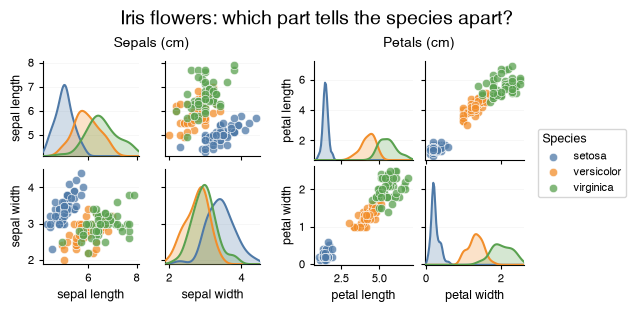

In [28]:
sepal_matrix = ScatterMatrix(
    data=sepals,
    hue="species",
    diagonal=SCATTER_MATRIX_DIAGONAL.KDE,
    # the petal matrix names the species
    show_legend=False,
    title="Sepals (cm)",
)
petal_matrix = ScatterMatrix(
    data=petals,
    hue="species",
    diagonal=SCATTER_MATRIX_DIAGONAL.KDE,
    legend={"title": "Species"},
    title="Petals (cm)",
)

Grid(
    [[sepal_matrix, petal_matrix]],
    title="Iris flowers: which part tells the species apart?",
    figsize=(6.3, 3.0),
).show()